# 🚗 Automotive Demand Forecasting — Chile & Peru  
### Classical, Classical + LLM-Augmented

**Objective**  
This notebook presents an end-to-end automotive demand forecasting analysis for monthly vehicle sales in **Chile and Peru**.  
Multiple modelling approaches are evaluated — from **interpretable classical models** to **LLM augmented classical models**.

**Models evaluated**
- Classical: SARIMAX  
- LLM-augmented: SARIMAX + economic news sentiment  

**Evaluation**
- Metrics: MAE, MAPE, wMAPE  
- Fixed **12-month hold-out** test period  
- Residual diagnostics & forecast stability checks  



## 1. Business Context & Objective

Accurate demand forecasting is critical in the **automotive industry**, where forecasts directly inform:
- Vehicle **inventory planning**
- **Pricing** and promotional strategy
- **Production allocation** and logistics
- Marketing investment decisions

Automotive demand is challenging to predict due to:
- Strong **seasonality**
- Sensitivity to **macroeconomic conditions** (inflation, interest rates, exchange rates)
- **External economic shocks** that are often first reflected in news and sentiment

Traditional statistical models offer **transparency and stability**, but may struggle to capture non-linear patterns or external signals.  
Conversely, machine learning, deep learning, and foundation models can improve accuracy, but introduce trade-offs in **interpretability, computational cost, and deployment complexity**.

**Project objectives**
- Forecast monthly vehicle sales for **Chile and Peru**
- Compare classical and LLM-augmented model approaches
- Evaluate models not only on accuracy, but also on residual diagnostics.


## 2. Data & Features

This section describes the datasets used for automotive demand forecasting, the feature construction process, and the evaluation setup.

### 2.1 Data Sources

The analysis is based on **monthly time-series data** for two automotive markets:

**Target variable**
- **Monthly vehicle sales**
  - Markets: **Chile** and **Peru**
  - Frequency: Monthly (month-end)
  - Used as the forecasting target

**Exogenous drivers**
- **Macroeconomic indicators**  
  Examples include inflation, interest rates, and other demand-relevant signals.
- **Economic news sentiment (NLP-derived)**  
  Monthly sentiment scores extracted from unstructured economic news and aligned with the sales data.

> All data sources were aligned to a common monthly frequency to ensure consistency across models.

### 2.2 Data Preparation & Alignment

To ensure comparability across models, the following preparation steps were applied:

- Converted all series to a **monthly time index**
- Aligned sales, macroeconomic variables, and sentiment features by date
- Checked for missing values and ensured consistent coverage across markets
- Applied identical preprocessing logic to **Chile and Peru**

These steps ensure that differences in performance reflect **model behaviour**, not data leakage or preprocessing inconsistencies.

### 2.3 Train / Test Split

A **fixed hold-out strategy** was used to evaluate all models fairly:

- **Training set:** All observations except the final 12 months  
- **Test set:** Final **12 months** of data (out-of-sample)

This approach:
- Mimics a real-world forecasting scenario
- Allows direct comparison across modelling approaches
- Prevents information leakage from future observations

> All reported metrics (MAE, MAPE, wMAPE) are computed on the same 12-month test window.

### 2.4 Feature Sets by Model Type

Different model families use different feature representations:

- **Classical models (SARIMAX)**  
  - Sales history  
  - Optional exogenous variables (macroeconomic indicators, news sentiment)

- **LLM-augmented forecasting**  
  - SARIMAX with **NLP-derived news sentiment** as an exogenous regressor

### 2.5 Summary

- Monthly vehicle sales for Chile and Peru form the forecasting target
- Macroeconomic variables and **NLP-derived news sentiment** are used as external drivers
- A consistent **12-month hold-out** window is applied across all models
- Feature construction is tailored to each model family while maintaining fairness


# **Data Cleaning**

## Imports & Display Options

In [ ]:
# STEP 1 – Libraries & display options

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.style.use("default")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## File Upload & Data Loading

In [ ]:
# STEP 2 – File upload (Colab) – upload the Chile & Peru ZIPs

from google.colab import files
uploaded = files.upload()   # choose Chile Dataset.zip and Peru Dataset.zip


Saving Chile Dataset.zip to Chile Dataset.zip
Saving Peru Dataset.zip to Peru Dataset.zip


In [ ]:
# Read vehicle & macro data FROM THE ZIP FILES

import os, zipfile

def find_zip(keyword):
    """Return first .zip file whose name contains keyword (case-insensitive)."""
    keyword = keyword.lower()
    for name in os.listdir('.'):
        if name.lower().endswith('.zip') and keyword in name.lower():
            return name
    raise FileNotFoundError(f"No zip file found containing: {keyword}")

chile_zip = find_zip("chile dataset")
peru_zip  = find_zip("peru dataset")

print("Using ZIP files:")
print("  Chile:", chile_zip)
print("  Peru :", peru_zip)

# ---- CHILE ----
with zipfile.ZipFile(chile_zip, "r") as z:
    # Check what's inside (you'll see full paths)
    print("\nChile ZIP contents:")
    print(z.namelist())

    with z.open("Chile Dataset/Vehicle_Data_Chile_1990_2025.xlsx") as f:
        veh_chile = pd.read_excel(f)

    with z.open("Chile Dataset/Exogenous_Variables_Chile.xlsx") as f:
        macro_chile = pd.read_excel(f)

# ---- PERU ----
with zipfile.ZipFile(peru_zip, "r") as z:
    print("\nPeru ZIP contents:")
    print(z.namelist())

    with z.open("Peru Dataset/Vehicle_Data_Peru_2010_2025.xlsx") as f:
        veh_peru = pd.read_excel(f)

    with z.open("Peru Dataset/Exogenous_Variables_Peru.xlsx") as f:
        macro_peru = pd.read_excel(f)

display(veh_chile.head())
display(macro_chile.head())
display(veh_peru.head())
display(macro_peru.head())


Using ZIP files:
  Chile: Chile Dataset.zip
  Peru : Peru Dataset.zip

Chile ZIP contents:
['Chile Dataset/', 'Chile Dataset/Exogenous_Variables_Chile.xlsx', 'Chile Dataset/TIV_Forecast_Data_Dictionary_Chile.xlsx', 'Chile Dataset/Vehicle_Data_Chile_1990_2025.xlsx']

Peru ZIP contents:
['Peru Dataset/', 'Peru Dataset/Exogenous_Variables_Peru.xlsx', 'Peru Dataset/TIV_Forecast_Data_Dictionary_Peru.xlsx', 'Peru Dataset/Vehicle_Data_Peru_2010_2025.xlsx']


,Año,ENE,FEB,MAR,ABR,MAY,JUN,JUL,AGO,SEP,OCT,NOV,DIC,TOTAL AÑO
0,1990,6766,4229,6200,5517,5683,5519,4730,5778,4924,"4,794.00","5,107.00","6,440.00","65,687.00"
1,1991,6360,4744,5372,5805,5675,6133,7719,7745,7494,"8,538.00","8,589.00","8,653.00","82,827.00"
2,1992,8654,8435,9912,10541,10328,9909,12278,15091,6762,"7,996.00","9,135.00","9,613.00","118,654.00"
3,1993,10300,9857,11826,10531,9094,8175,9678,9836,9952,"8,732.00","8,841.00","10,578.00","117,400.00"
4,1994,9036,7881,10019,8378,8647,8676,8852,9579,8570,"8,557.00","9,919.00","10,213.00","108,327.00"


,Date,Balance of Trade,Bank Lending Rate,Building Permits,Business Confidence,CPI Transportation,Consumer Confidence,Consumer Credit,Consumer Price Index CPI,Core Consumer Prices,...,Imports,Industrial Production,Inflation Rate,Labor Force Participation Rate,Leading Economic Index,Private Sector Credit,Producer Prices,Retail Sales MoM,Unemployed Persons,Wages
0,31-08-2010,"1,421.28",6.91,15376,58.80,NaN,49.40,"9,185.00",58.62,94.04,...,"4,927.07",5.60,2.60,59.80,8.10,"72,376.27",NaN,-3.40,671.60,"2,665.46"
1,30-09-2010,"1,442.98",6.87,7553,60.60,NaN,53.80,"9,269.00",58.85,94.45,...,"4,733.40",0.10,1.90,60.40,6.60,"72,722.94",NaN,4.90,653.45,"2,684.97"
2,31-10-2010,"1,289.24",7.14,11546,60.18,NaN,56.50,"9,372.00",58.91,94.38,...,"5,082.70",-0.90,2.00,60.30,6.70,"73,751.29",NaN,-0.50,628.53,"2,695.37"
3,30-11-2010,"1,497.92",7.19,10744,60.41,NaN,53.70,"9,547.00",58.95,94.30,...,"5,060.56",3.50,2.50,60.50,8.50,"74,323.63",NaN,1.50,584.32,"2,701.86"
4,31-12-2010,"2,282.62",7.38,16629,56.81,NaN,52.20,"9,739.00",59.02,94.55,...,"5,522.91",3.70,3.00,61.00,7.20,"74,647.45",NaN,2.20,588.40,"2,730.32"


,Month,Cars
0,2010-01-01,6450
1,2010-02-01,6421
2,2010-03-01,7426
3,2010-04-01,7252
4,2010-05-01,8260


,Month,GDP,Population,Balance of Trade,Business Confidence,Consumer Credit,Consumer Price Index CPI,Copper Production,Crude Oil Production,Exports,Gasoline Prices,Gold Production,Imports,Industrial Production,Inflation Rate,Minimum Wages,Private Sector Credit,Unemployed Persons,Wages
0,2010-01-01,11.78,2.30,345.54,78.07,"22,846.18",71.08,"135,978.48",26.98,"1,085.91",1.31,"9,033.99","1,740.79",7.07,1.89,550.00,"61,732.80",256.76,974.42
1,2010-02-01,11.91,2.25,360.22,77.13,"23,147.85",71.06,"131,605.99",32.77,"1,343.41",1.32,"9,504.57","1,851.49",7.22,1.94,550.00,"62,113.60",268.52,991.39
2,2010-03-01,12.03,2.39,376.48,76.10,"23,481.83",71.04,"126,765.01",39.19,"1,628.51",1.33,"10,025.58","1,974.04",7.38,2.00,550.00,"62,535.20",281.54,"1,010.17"
3,2010-04-01,12.15,2.37,392.21,75.10,"23,805.04",71.02,"122,080.20",45.40,"1,904.41",1.34,"10,529.78","2,092.64",7.54,2.06,550.00,"62,943.20",294.14,"1,028.35"
4,2010-05-01,12.27,2.41,408.46,74.07,"24,139.02",71.00,"117,239.23",51.82,"2,189.51",1.35,"11,050.79","2,215.19",7.71,2.13,550.00,"63,364.80",307.16,"1,047.14"


## Reshape Vehicle Data → Monthly Time Series

In [ ]:
whos

Variable      Type          Data/Info
-------------------------------------
chile_zip     str           Chile Dataset.zip
f             ZipExtFile    <zipfile.ZipExtFile [closed]>
files         module        <module 'google.colab.fil<...>s/google/colab/files.py'>
find_zip      function      <function find_zip at 0x7e38c2ebf920>
macro_chile   DataFrame                Date  Balance <...>\n[179 rows x 25 columns]
macro_peru    DataFrame              Month   GDP  Pop<...>\n[204 rows x 19 columns]
np            module        <module 'numpy' from '/us<...>kages/numpy/__init__.py'>
os            module        <module 'os' (frozen)>
pd            module        <module 'pandas' from '/u<...>ages/pandas/__init__.py'>
peru_zip      str           Peru Dataset.zip
plt           module        <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
sm            module        <module 'statsmodels.api'<...>ages/statsmodels/api.py'>
uploaded      dict          n=2
veh_chile     DataFrame          Año  

In [ ]:
# Chile: from Año + ENE..DIC to monthly time series

chile_wide = veh_chile.copy()

month_cols = ["ENE", "FEB", "MAR", "ABR", "MAY", "JUN",
              "JUL", "AGO", "SEP", "OCT", "NOV", "DIC"]

month_map = {
    "ENE": 1, "FEB": 2, "MAR": 3, "ABR": 4,
    "MAY": 5, "JUN": 6, "JUL": 7, "AGO": 8,
    "SEP": 9, "OCT": 10, "NOV": 11, "DIC": 12
}

chile_long = chile_wide.melt(
    id_vars="Año",
    value_vars=month_cols,
    var_name="Month_name",
    value_name="Vehicle_Sales"
)

chile_long["Month"] = chile_long["Month_name"].map(month_map)
chile_long["Date"] = pd.to_datetime(
    dict(year=chile_long["Año"], month=chile_long["Month"], day=1)
)

chile_long = (
    chile_long[["Date", "Año", "Month", "Vehicle_Sales"]]
    .sort_values("Date")
    .reset_index(drop=True)
)

chile_long.head()


,Date,Año,Month,Vehicle_Sales
0,1990-01-01,1990,1,"6,766.00"
1,1990-02-01,1990,2,"4,229.00"
2,1990-03-01,1990,3,"6,200.00"
3,1990-04-01,1990,4,"5,517.00"
4,1990-05-01,1990,5,"5,683.00"


In [ ]:
# Peru: tidy monthly time series

peru_long = veh_peru.copy()

# Assuming columns Month (date) and Cars (sales)
peru_long = peru_long.rename(columns={"Month": "Date", "Cars": "Vehicle_Sales"})

peru_long["Date"] = pd.to_datetime(peru_long["Date"])
peru_long["Año"]  = peru_long["Date"].dt.year
peru_long["Month"] = peru_long["Date"].dt.month

peru_long = peru_long[["Date", "Año", "Month", "Vehicle_Sales"]].sort_values("Date")
peru_long.head()


,Date,Año,Month,Vehicle_Sales
0,2010-01-01,2010,1,6450
1,2010-02-01,2010,2,6421
2,2010-03-01,2010,3,7426
3,2010-04-01,2010,4,7252
4,2010-05-01,2010,5,8260


In [ ]:
pe_ml = peru_long.copy()


In [ ]:
ch_ml = chile_long.copy()


# **EDA**

## Time-Series Trends & Seasonality

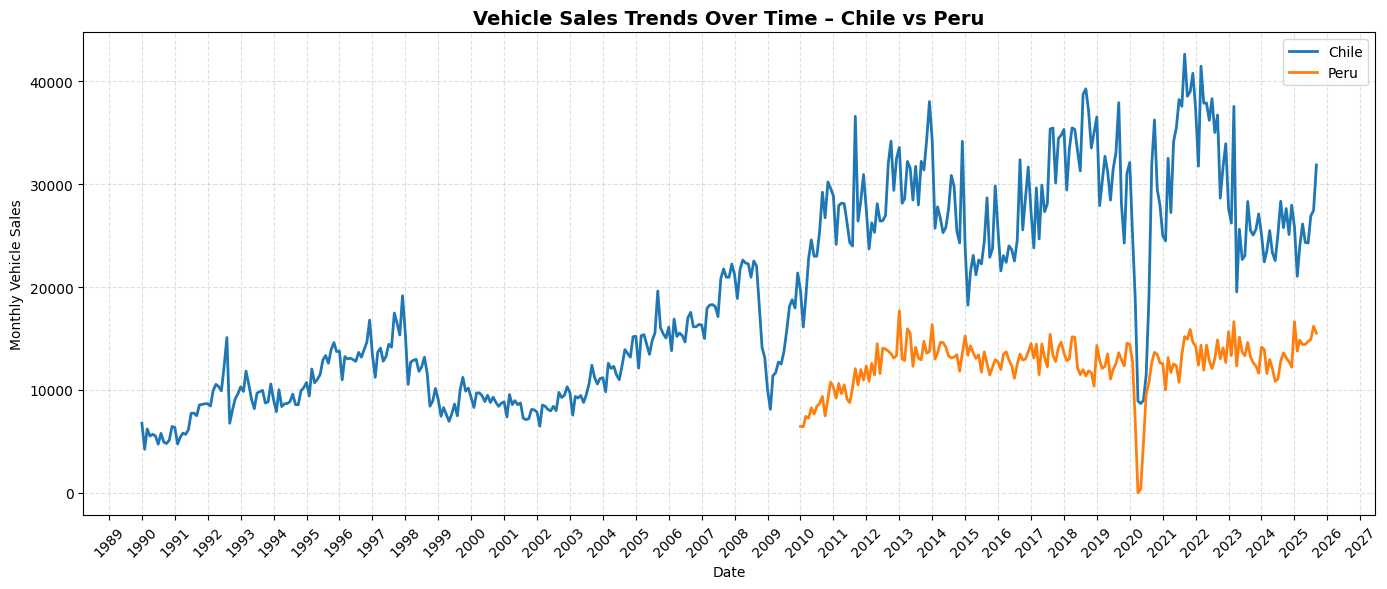

In [ ]:
# ==============================
# TIME-SERIES TREND PLOTS
# ==============================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(14,6))

# Chile
plt.plot(ch_ml["Date"], ch_ml["Vehicle_Sales"], label="Chile", color="#1f77b4", linewidth=2)

# Peru
plt.plot(pe_ml["Date"], pe_ml["Vehicle_Sales"], label="Peru", color="#ff7f0e", linewidth=2)

# Formatting
plt.title("Vehicle Sales Trends Over Time – Chile vs Peru", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Monthly Vehicle Sales")

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


### Vehicle Sales Trends: Chile vs Peru

The chart compares monthly vehicle sales trends in Chile and Peru over time.

**Chile**
- Long historical coverage with multiple economic cycles.
- Clear long-term upward trend, particularly from the mid-2000s onward.
- Higher sales volumes but noticeably more volatile.
- Sharp decline around 2020, followed by recovery with continued fluctuations.

**Peru**
- Shorter time series compared to Chile.
- More stable and smoother growth pattern.
- Lower overall sales volumes.
- 2020 downturn is visible, but recovery is steadier and less volatile.

**Key takeaway**
- Chile represents a larger but more volatile market.
- Peru is smaller but more stable and predictable.
- These differences are important when selecting forecasting models:
  volatility-aware models suit Chile, while simpler trend-focused models work well for Peru.


## Seasonality Analysis

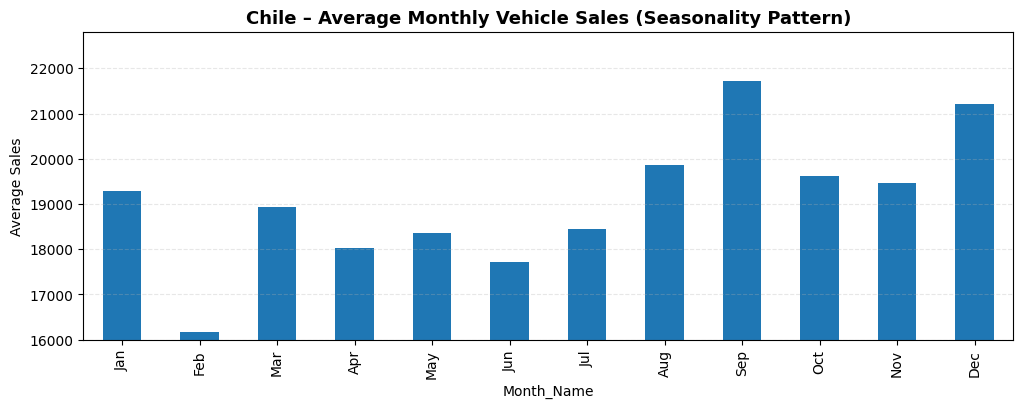

In [ ]:
# Extract month numbers and names
ch_ml["Month_Name"] = ch_ml["Date"].dt.strftime("%b")

plt.figure(figsize=(12,4))
ch_ml.groupby("Month_Name")["Vehicle_Sales"].mean().reindex(
    ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
).plot(kind="bar", color="#1f77b4")

# Set y-axis minimum
plt.ylim(bottom=16000)

plt.title("Chile – Average Monthly Vehicle Sales (Seasonality Pattern)", fontsize=13, fontweight="bold")
plt.ylabel("Average Sales")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()


### Chile – Seasonal Pattern in Vehicle Sales

Average monthly vehicle sales in Chile show a clear and consistent seasonal pattern.

* Sales are lowest in February, reflecting a post-holiday slowdown.
* Sales increase sharply from August onwards, with peaks in September and December.
* Overall, the second half of the year outperforms the first, indicating stronger year-end demand.

### **Key takeaway**
Chile’s vehicle market exhibits strong, repeatable seasonality, particularly in late Q3 and Q4.

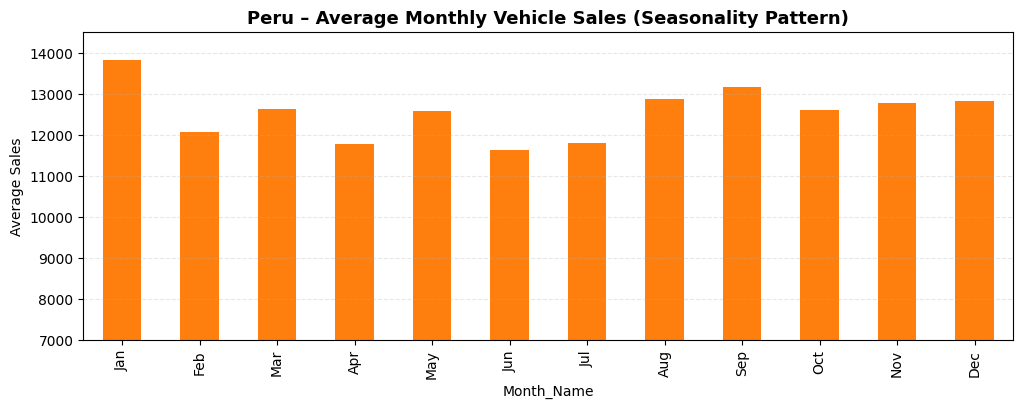

In [ ]:
pe_ml["Month_Name"] = pe_ml["Date"].dt.strftime("%b")

plt.figure(figsize=(12,4))
pe_ml.groupby("Month_Name")["Vehicle_Sales"].mean().reindex(
    ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
).plot(kind="bar", color="#ff7f0e")

# Set y-axis minimum
plt.ylim(bottom=7000)

plt.title("Peru – Average Monthly Vehicle Sales (Seasonality Pattern)", fontsize=13, fontweight="bold")
plt.ylabel("Average Sales")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()


### Peru – Seasonal Pattern in Vehicle Sales

Average monthly vehicle sales in Peru display milder seasonality than Chile.

Sales remain relatively stable throughout the year.

## **Key takeaway**
Peru’s vehicle market shows weaker and less pronounced seasonality.
Forecasting models may rely more on trend and external drivers, with seasonal components playing a secondary role.


## Merge Macroeconomic Data

In [ ]:
# STEP 5A – Chile macro monthly merge

mc = macro_chile.copy()
mc["Date"] = pd.to_datetime(mc["Date"], dayfirst=True)
mc["Año"]   = mc["Date"].dt.year
mc["Month"] = mc["Date"].dt.month

chile_model = chile_long.merge(
    mc,
    on=["Año", "Month"],
    how="left",
    suffixes=("", "_macro")
)

print(chile_model.shape)
chile_model.dtypes.head(20)


(432, 29)


,0
Date,datetime64[ns]
Año,int64
Month,int64
Vehicle_Sales,float64
Date_macro,datetime64[ns]
Balance of Trade,float64
Bank Lending Rate,float64
Building Permits,float64
Business Confidence,float64
CPI Transportation,float64


In [ ]:
# STEP 5B – Peru macro monthly merge

mp = macro_peru.copy()

# macro_peru usually has a 'Month' column with text dates → convert
if "Month" in mp.columns:
    mp["Date"] = pd.to_datetime(mp["Month"])
else:
    mp["Date"] = pd.to_datetime(mp["Date"])

mp["Año"] = mp["Date"].dt.year
mp["Month"] = mp["Date"].dt.month

peru_model = peru_long.merge(
    mp,
    on=["Date", "Año", "Month"],
    how="left",
    suffixes=("", "_macro")
)

print(peru_model.shape)
peru_model.dtypes.head(20)


(189, 22)


,0
Date,datetime64[ns]
Año,int32
Month,int32
Vehicle_Sales,int64
GDP,float64
Population,float64
Balance of Trade,float64
Business Confidence,float64
Consumer Credit,float64
Consumer Price Index CPI,float64


## Correlation Structure

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


chile_long shape: (432, 5)
macro_chile shape: (179, 27)
Merged ch_ml shape: (179, 29)
                                                  0                    1  \
Date                            2010-08-01 00:00:00  2010-09-01 00:00:00   
Año                                            2010                 2010   
Month_num                                         8                    9   
Vehicle_Sales                             25,397.00            29,221.00   
Balance of Trade                           1,421.28             1,442.98   
Bank Lending Rate                              6.91                 6.87   
Building Permits                              15376                 7553   
Business Confidence                           58.80                60.60   
CPI Transportation                              NaN                  NaN   
Consumer Confidence                           49.40                53.80   
Consumer Credit                            9,185.00             9,269.00   
Co

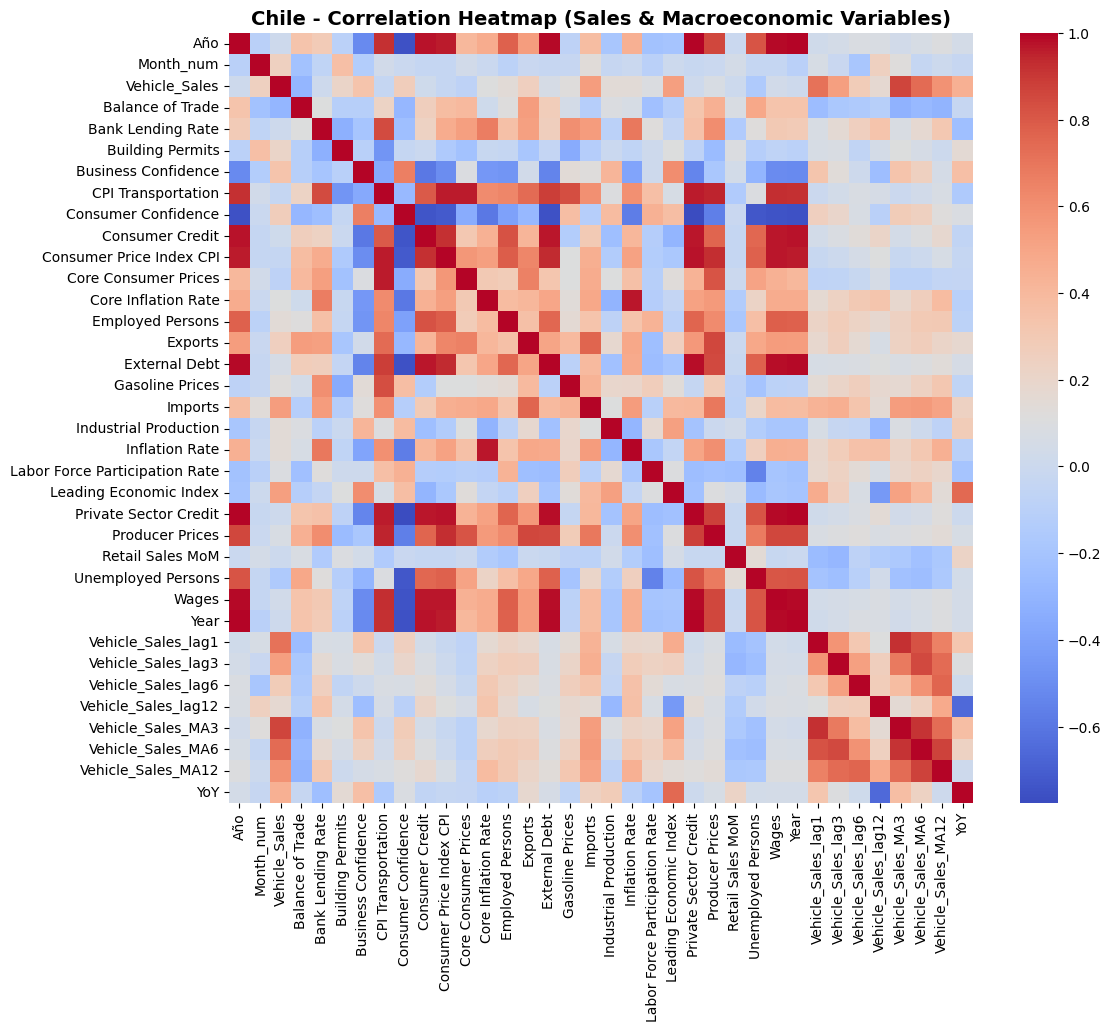

In [ ]:
# === 1. Make sure Chile sales has year + month ===
chile_long["Date"] = pd.to_datetime(chile_long["Date"])
chile_long["Año"] = chile_long["Date"].dt.year
chile_long["Month_num"] = chile_long["Date"].dt.month

# === 2. Make sure macro_chile has year + month ===
macro_chile["Date"] = pd.to_datetime(macro_chile["Date"], dayfirst=True, errors="coerce")
macro_chile["Year"] = macro_chile["Date"].dt.year
macro_chile["Month_num"] = macro_chile["Date"].dt.month

# Quick check
print("chile_long shape:", chile_long.shape)
print("macro_chile shape:", macro_chile.shape)

# === 3. Merge on (year, month) ===
ch_ml = pd.merge(
    chile_long[["Date", "Año", "Month_num", "Vehicle_Sales"]],
    macro_chile.drop(columns=["Date"]),   # we keep Year + Month_num from macro
    left_on=["Año", "Month_num"],
    right_on=["Year", "Month_num"],
    how="inner"
)

print("Merged ch_ml shape:", ch_ml.shape)
print(ch_ml.head().T)   # see what it looks like

# === 4. Create lag + MA features for Vehicle_Sales ===
for lag in [1, 3, 6, 12]:
    ch_ml[f"Vehicle_Sales_lag{lag}"] = ch_ml["Vehicle_Sales"].shift(lag)

for win, name in [(3, "MA3"), (6, "MA6"), (12, "MA12")]:
    ch_ml[f"Vehicle_Sales_{name}"] = (
        ch_ml["Vehicle_Sales"].rolling(window=win, min_periods=1).mean()
    )

ch_ml["YoY"] = ch_ml["Vehicle_Sales"].pct_change(12)

# === 5. Strong numeric clean for ALL non-Date columns ===
for col in ch_ml.columns:
    if col != "Date":
        ch_ml[col] = (
            ch_ml[col]
            .astype(str)
            .str.replace(r"[^0-9\.\-]", "", regex=True)  # keep only digits, dot, minus
        )
        ch_ml[col] = pd.to_numeric(ch_ml[col], errors="coerce")

print("\nNumeric summary (first few cols):")
print(ch_ml.describe().iloc[:, :5])

# === 6. Correlation + heatmap ===
corr_ch = ch_ml.corr(numeric_only=True)
print("\nChile corr shape:", corr_ch.shape)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_ch,
    cmap="coolwarm",
    annot=False
)
plt.title(
    "Chile - Correlation Heatmap (Sales & Macroeconomic Variables)",
    fontsize=14,
    fontweight="bold"
)
plt.show()


### Chile – Correlation Analysis (Vehicle Sales & Macroeconomic Variables)

The heatmap shows pairwise correlations between vehicle sales, their lags, and a broad set of macroeconomic indicators for Chile.

**Key takeaway**
- Vehicle sales in Chile are driven by strong autoregressive dynamics and credit- and income-related macro factors.
- Multivariate models should therefore combine lagged structure with selected macro variables, applying careful feature selection to manage multicollinearity.


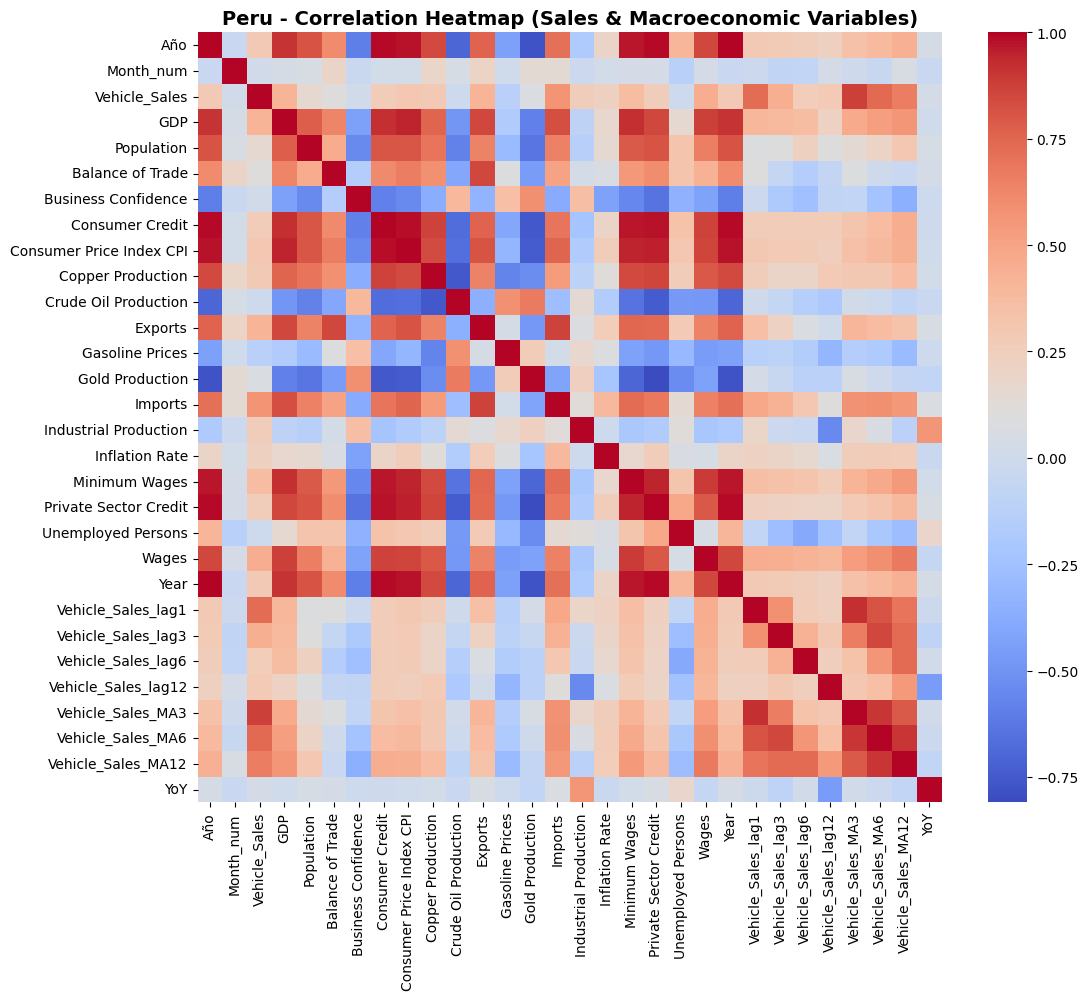

In [ ]:
# PERU – Correlation Heatmap (Sales & Macroeconomic Variables)

# 1. Make sure Peru sales has year + month
peru_long["Date"] = pd.to_datetime(peru_long["Date"])
peru_long["Año"] = peru_long["Date"].dt.year
peru_long["Month_num"] = peru_long["Date"].dt.month

# 2. Make sure macro_peru has Date, Year, Month_num
#    (original date column is usually called "Month")
if "Month" in macro_peru.columns:
    macro_peru = macro_peru.rename(columns={"Month": "Date"})

macro_peru["Date"] = pd.to_datetime(macro_peru["Date"], dayfirst=True, errors="coerce")
macro_peru["Year"] = macro_peru["Date"].dt.year
macro_peru["Month_num"] = macro_peru["Date"].dt.month

# 3. Merge sales + macro on (year, month)
pe_ml = pd.merge(
    peru_long[["Date", "Año", "Month_num", "Vehicle_Sales"]],
    macro_peru.drop(columns=["Date"]),
    left_on=["Año", "Month_num"],
    right_on=["Year", "Month_num"],
    how="inner"
)

# 4. Create lag + moving-average features for Vehicle_Sales
for lag in [1, 3, 6, 12]:
    pe_ml[f"Vehicle_Sales_lag{lag}"] = pe_ml["Vehicle_Sales"].shift(lag)

for win, name in [(3, "MA3"), (6, "MA6"), (12, "MA12")]:
    pe_ml[f"Vehicle_Sales_{name}"] = (
        pe_ml["Vehicle_Sales"].rolling(window=win, min_periods=1).mean()
    )

pe_ml["YoY"] = pe_ml["Vehicle_Sales"].pct_change(12)

# 5. Strong numeric clean for ALL non-Date columns
for col in pe_ml.columns:
    if col != "Date":
        pe_ml[col] = (
            pe_ml[col]
            .astype(str)
            .str.replace(r"[^0-9\.\-]", "", regex=True)  # keep only digits, dot, minus
        )
        pe_ml[col] = pd.to_numeric(pe_ml[col], errors="coerce")

# 6. Correlation + heatmap
corr_pe = pe_ml.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_pe,
    cmap="coolwarm",
    annot=False
)
plt.title(
    "Peru - Correlation Heatmap (Sales & Macroeconomic Variables)",
    fontsize=14,
    fontweight="bold"
)
plt.show()


### Peru – Correlation Analysis (Vehicle Sales & Macroeconomic Variables)

The heatmap shows correlations between vehicle sales, their lagged features, and key macroeconomic indicators for Peru.

**Key takeaway**
* Vehicle sales in Peru are primarily driven by economic growth and credit availability, with strong temporal persistence.
* Multivariate models should therefore emphasise lagged structure and trend, while applying careful feature selection or regularisation to manage multicollinearity..


## Macro Panels

**Chile Macro Trend Panel**

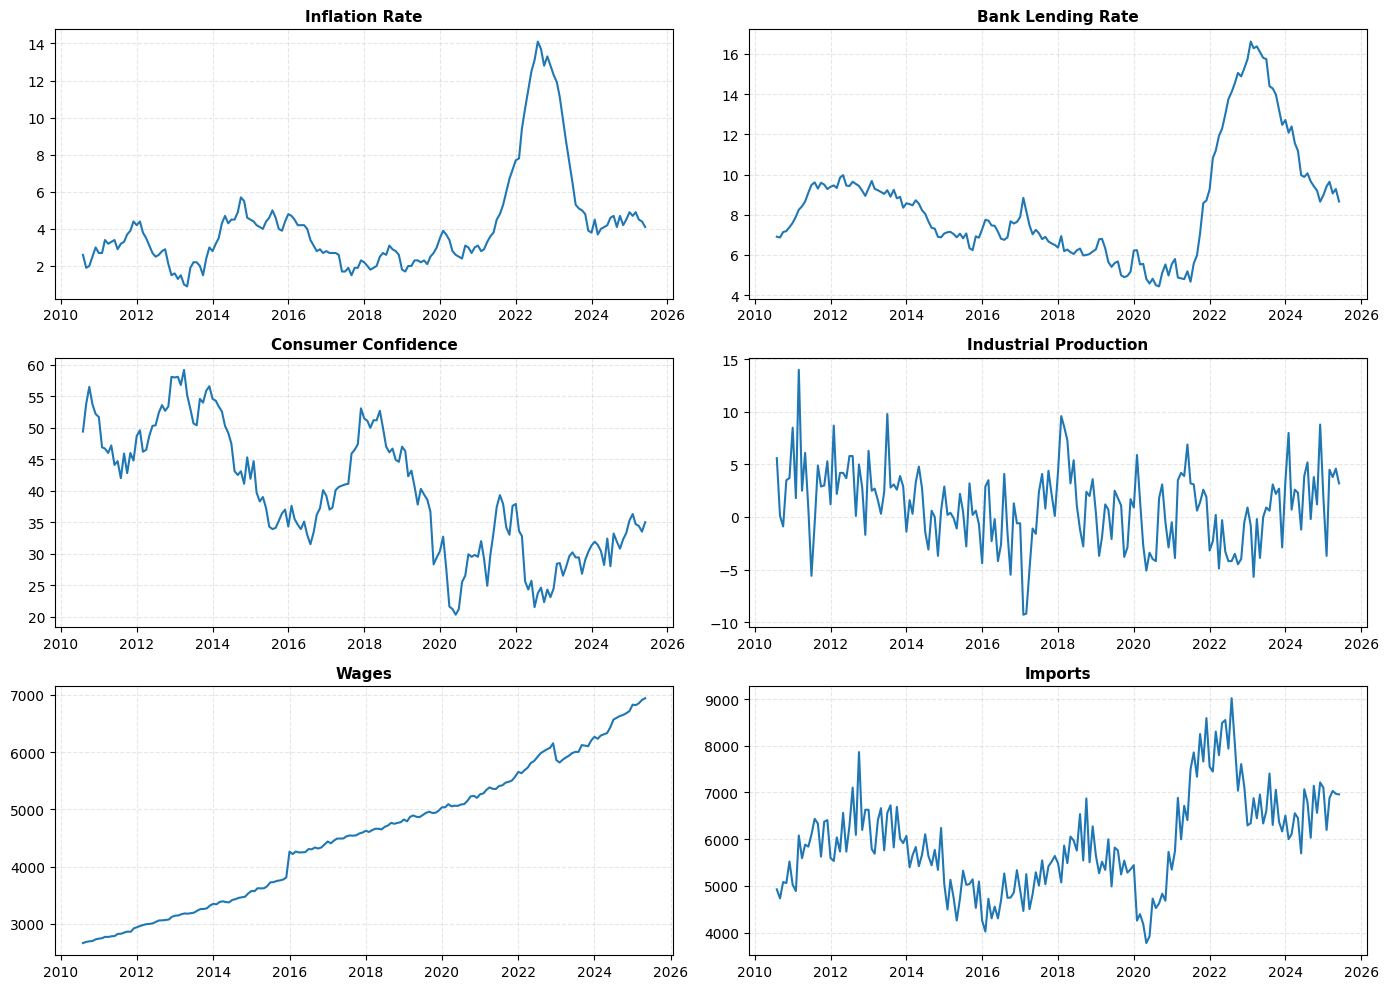

In [ ]:
macro_cols_chile = ["Inflation Rate", "Bank Lending Rate", "Consumer Confidence",
                    "Industrial Production", "Wages", "Imports"]

plt.figure(figsize=(14,10))
for i, col in enumerate(macro_cols_chile, 1):
    plt.subplot(3, 2, i)
    plt.plot(ch_ml["Date"], ch_ml[col], color="#1f77b4")
    plt.title(col, fontsize=11, fontweight="bold")
    plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


### Chile – Key Macroeconomic Trends

- Key macro indicators show a clear shift in Chile’s economic environment post-2020.

- Inflation and interest rates surged from 2021–2023, tightening credit conditions.

- Consumer confidence collapsed in 2020 and has only partially recovered.

- Economic activity (industrial production and imports) remains volatile.

- Wages continue to trend upward, partly offset by higher inflation.

**Key takeaway**
Vehicle demand in Chile is constrained by tight credit and weak confidence, despite rising nominal wages.
These variables provide important explanatory signals when extending forecasts beyond univariate models.


**Peru Macro Trend Panel**

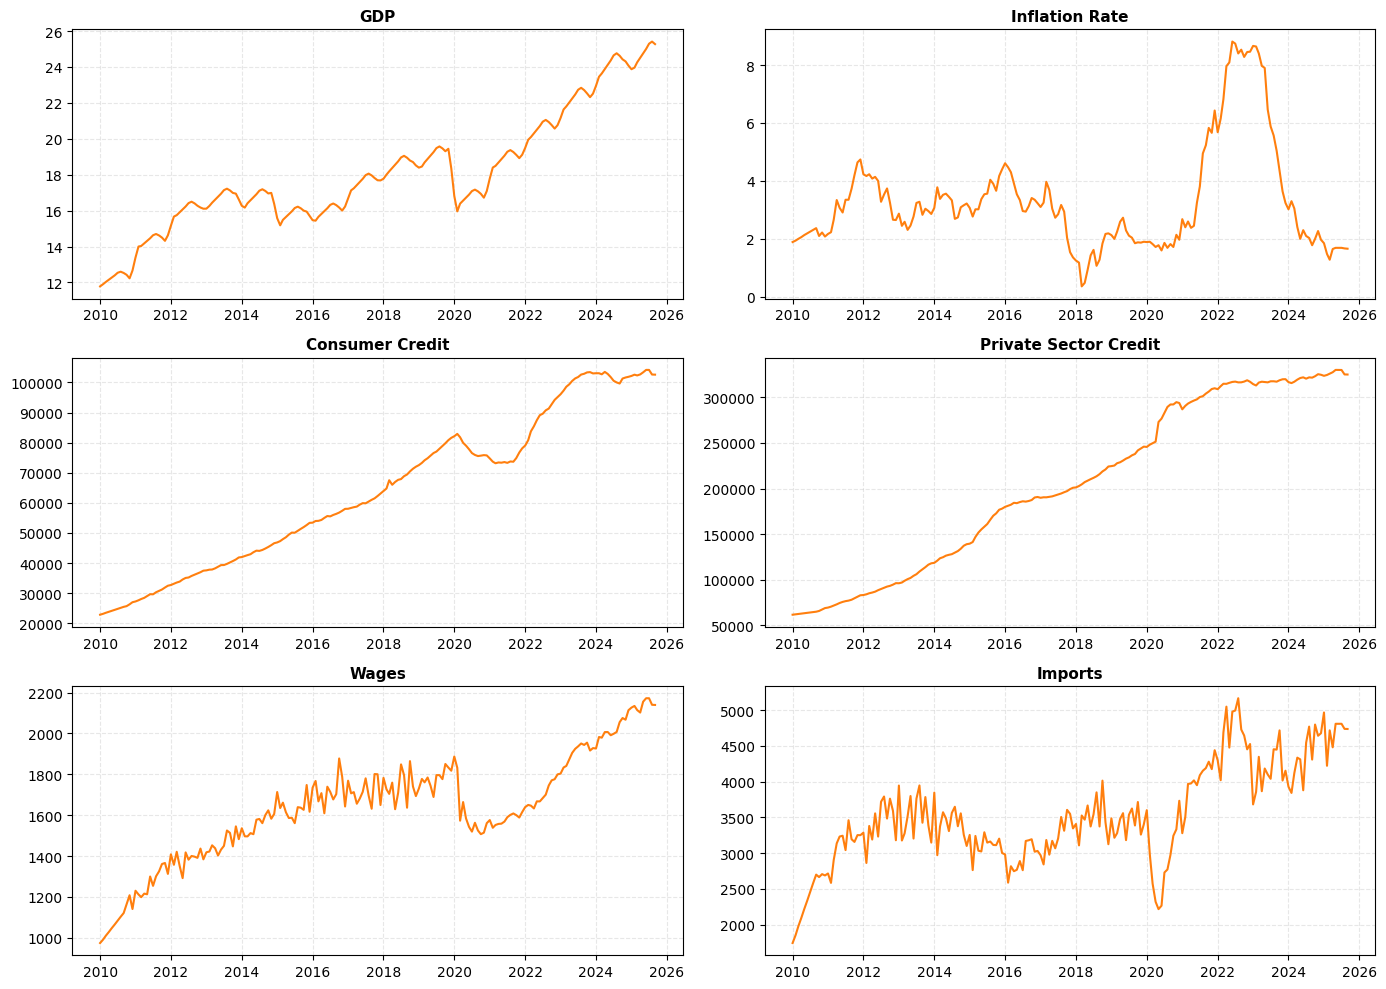

In [ ]:
macro_cols_peru = ["GDP", "Inflation Rate", "Consumer Credit", "Private Sector Credit",
                   "Wages", "Imports"]

plt.figure(figsize=(14,10))
for i, col in enumerate(macro_cols_peru, 1):
    plt.subplot(3, 2, i)
    plt.plot(pe_ml["Date"], pe_ml[col], color="#ff7f0e")
    plt.title(col, fontsize=11, fontweight="bold")
    plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


### Peru – Key Macroeconomic Trends
Key macro indicators point to a relatively supportive demand environment in Peru.

- Economic growth: GDP shows a clear long-term upward trend, with a sharp contraction in 2020 followed by a strong and sustained recovery.

- Inflation and credit: Inflation spiked in 2022–2023 but eased quickly, while consumer and private sector credit continued to expand.

- Income dynamics: Wages increased over the long run, with a brief dip in 2020 followed by a strong rebound.

- Economic activity: Imports track the business cycle closely, contracting in 2020 and rebounding during the recovery.

**Key takeaway**
Peru’s vehicle demand is supported by economic growth, rising incomes, and expanding credit, with shocks tending to be short-lived.
These conditions make macroeconomic variables valuable but less destabilising inputs for multivariate forecasting models.

## EDA Summary


The EDA examines monthly vehicle sales in Chile and Peru to identify patterns that inform forecasting model design.

- **Chile** shows a **strong upward trend, high volatility, and pronounced seasonality**, with demand peaking in late Q3–Q4.

- **Peru **exhibits **smoother growth, lower volatility, and weak seasonality**, indicating a more stable demand profile.

- Vehicle sales in both markets display strong persistence, with lagged sales explaining a large share of variation.

- Positive relationships with income and credit variables highlight the role of household purchasing power, while inflation and interest rates show weaker or negative associations.

- High correlations among macro variables indicate multicollinearity, favouring careful feature selection.

- Modelling implication
The EDA supports a strategy that combines seasonal and autoregressive models (particularly for Chile) with select macro and sentiment-based exogenous signals, while benchmarking against ML, deep learning, and foundation models.

## Missing values

In [ ]:
def missing_values_report(df, name):
    print(f"\n===== {name} MISSING VALUES =====")
    missing = df.isna().sum().sort_values(ascending=False)
    print(missing[missing > 0])

missing_values_report(ch_ml, "CHILE")
missing_values_report(pe_ml, "PERU")



===== CHILE MISSING VALUES =====
CPI Transportation                101
Gasoline Prices                    27
Producer Prices                    17
Vehicle_Sales_lag12                12
YoY                                12
Vehicle_Sales_lag6                  6
Retail Sales MoM                    4
Vehicle_Sales_lag3                  3
Labor Force Participation Rate      1
Wages                               1
Private Sector Credit               1
External Debt                       1
Consumer Credit                     1
Vehicle_Sales_lag1                  1
dtype: int64

===== PERU MISSING VALUES =====
YoY                    13
Vehicle_Sales_lag12    12
Vehicle_Sales_lag6      6
Vehicle_Sales_lag3      3
Vehicle_Sales_lag1      1
dtype: int64


In [ ]:
ch_ml = ch_ml.ffill().bfill()
pe_ml= pe_ml.ffill().bfill()

missing_values_report(ch_ml, "CHILE")
missing_values_report(pe_ml, "PERU")



===== CHILE MISSING VALUES =====
Series([], dtype: int64)

===== PERU MISSING VALUES =====
Series([], dtype: int64)


# **Classical Methods**

## Backtesting function for SARIMA & SARIMAX

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
import pandas as pd

def backtest_sarimax(df, target, exog_cols=None, n_test=24,
                     order=(1,1,1), seasonal_order=(1,1,1,12)):

    df_bt = df.sort_values("Date").reset_index(drop=True).copy()
    df_bt = df_bt.dropna(subset=[target])

    # Exogenous data
    if exog_cols is not None:
        exog_all = df_bt[exog_cols]
    else:
        exog_all = None

    results = []
    n = len(df_bt)
    n_test = min(n_test, max(1, n - 24))
    start_idx = n - n_test

    for i in range(start_idx, n):

        train_y = df_bt[target].iloc[:i]
        test_y  = df_bt[target].iloc[i:i+1]

        if exog_cols is not None:
            train_ex = exog_all.iloc[:i]
            test_ex  = exog_all.iloc[i:i+1]
        else:
            train_ex = None
            test_ex  = None

        model = SARIMAX(train_y,
                        exog=train_ex,
                        order=order,
                        seasonal_order=seasonal_order)

        fit = model.fit(disp=False)
        pred = float(fit.predict(start=train_y.index[-1]+1,
                                 end=train_y.index[-1]+1,
                                 exog=test_ex))

        actual_val = float(test_y.values[0])
        mae_val    = abs(actual_val - pred)
        mape_val   = abs(actual_val - pred)/abs(actual_val)*100 if actual_val != 0 else np.nan

        results.append({
            "Date": df_bt["Date"].iloc[i],
            "actual": actual_val,
            "pred": pred,
            "mae": mae_val,
            "mape": mape_val
        })

    return pd.DataFrame(results)


In [ ]:
bt_ch_sarima = backtest_sarimax(
    ch_ml,
    target="Vehicle_Sales",
    exog_cols=None,              # SARIMA = no macro
    n_test=24,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

print("Chile SARIMA:", bt_ch_sarima.shape)
bt_ch_sarima.describe()


/tmp/ipykernel_1226/1464971019.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(start=train_y.index[-1]+1,
/tmp/ipykernel_1226/1464971019.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(start=train_y.index[-1]+1,
/tmp/ipykernel_1226/1464971019.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(start=train_y.index[-1]+1,
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_1226/1464971019.py:40: FutureWarning: Calling float on a s

Chile SARIMA: (24, 5)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_1226/1464971019.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(start=train_y.index[-1]+1,


,Date,actual,pred,mae,mape
count,24,24.00,24.00,24.00,24.00
mean,2024-06-16 04:00:00,"25,110.50","25,047.68","2,110.48",8.36
min,2023-07-01 00:00:00,"21,044.00","19,074.17",45.55,0.16
25%,2023-12-24 06:00:00,"23,882.25","23,182.77",495.83,2.29
50%,2024-06-16 00:00:00,"25,110.00","25,032.00","1,574.30",6.63
75%,2024-12-08 18:00:00,"25,908.50","27,017.25","3,024.75",11.80
max,2025-06-01 00:00:00,"28,335.00","31,716.24","6,415.83",25.17
std,NaN,"1,912.85","3,099.07","1,964.96",7.64


In [ ]:
bt_pe_sarima = backtest_sarimax(
    pe_ml,
    target="Vehicle_Sales",
    exog_cols=None,
    n_test=24,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

print("Peru SARIMA:", bt_pe_sarima.shape)
bt_pe_sarima.describe()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_1226/1464971019.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(start=train_y.index[-1]+1,
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespa

Peru SARIMA: (24, 5)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_1226/1464971019.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(start=train_y.index[-1]+1,


,Date,actual,pred,mae,mape
count,24,24.00,24.00,24.00,24.00
mean,2024-09-15 13:00:00,"13,460.46","13,456.58",942.38,7.11
min,2023-10-01 00:00:00,"10,837.00","10,781.75",2.97,0.02
25%,2024-03-24 06:00:00,"12,294.50","12,706.71",425.50,2.91
50%,2024-09-16 00:00:00,"13,369.00","13,318.73",617.34,4.71
75%,2025-03-08 18:00:00,"14,499.75","14,149.78","1,088.99",8.65
max,2025-09-01 00:00:00,"16,629.00","16,221.59","3,359.72",28.99
std,NaN,"1,563.59","1,314.57",835.95,6.61


In [ ]:
ch_exog = ["Inflation Rate", "Bank Lending Rate", "Imports"]

bt_ch_sarimax = backtest_sarimax(
    ch_ml,
    target="Vehicle_Sales",
    exog_cols=ch_exog,
    n_test=24,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

print("Chile SARIMAX:", bt_ch_sarimax.shape)
bt_ch_sarimax.describe()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_1226/1464971019.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(start=train_y.index[-1]+1,
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_1226/1464971019.py:40: FutureWarning: Calling float on a single element Ser

Chile SARIMAX: (24, 5)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_1226/1464971019.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(start=train_y.index[-1]+1,


,Date,actual,pred,mae,mape
count,24,24.00,24.00,24.00,24.00
mean,2024-06-16 04:00:00,"25,110.50","25,764.78","1,770.10",7.03
min,2023-07-01 00:00:00,"21,044.00","20,527.59",240.02,0.99
25%,2023-12-24 06:00:00,"23,882.25","24,527.35",830.00,3.31
50%,2024-06-16 00:00:00,"25,110.00","25,489.77","1,754.94",7.32
75%,2024-12-08 18:00:00,"25,908.50","27,436.14","2,248.87",8.72
max,2025-06-01 00:00:00,"28,335.00","30,924.72","5,421.72",21.26
std,NaN,"1,912.85","2,784.41","1,231.40",4.77


In [ ]:
pe_exog = ["GDP", "Inflation Rate", "Imports"]

bt_pe_sarimax = backtest_sarimax(
    pe_ml,
    target="Vehicle_Sales",
    exog_cols=pe_exog,
    n_test=24,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

print("Peru SARIMAX:", bt_pe_sarimax.shape)
bt_pe_sarimax.describe()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_1226/1464971019.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(start=train_y.index[-1]+1,
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespa

Peru SARIMAX: (24, 5)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_1226/1464971019.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(start=train_y.index[-1]+1,


,Date,actual,pred,mae,mape
count,24,24.00,24.00,24.00,24.00
mean,2024-09-15 13:00:00,"13,460.46","13,103.55","1,181.60",8.80
min,2023-10-01 00:00:00,"10,837.00","9,982.72",298.00,2.33
25%,2024-03-24 06:00:00,"12,294.50","12,138.21",590.49,4.52
50%,2024-09-16 00:00:00,"13,369.00","13,057.56",994.54,7.12
75%,2025-03-08 18:00:00,"14,499.75","13,930.76","1,557.02",11.29
max,2025-09-01 00:00:00,"16,629.00","16,468.40","2,970.28",22.93
std,NaN,"1,563.59","1,504.84",714.10,5.56


In [ ]:
[x for x in globals().keys() if x.startswith("bt_")]


['bt_ch_sarima', 'bt_pe_sarima', 'bt_ch_sarimax', 'bt_pe_sarimax']

In [ ]:
def summarise_backtest(bt_df, country, model_name):
    return {
        "Country": country,
        "Model": model_name,
        "MAE_mean": bt_df["mae"].mean(),
        "MAPE_mean": bt_df["mape"].mean()
    }

summary_sarima = pd.DataFrame([
    summarise_backtest(bt_ch_sarima,  "Chile", "SARIMA"),
    summarise_backtest(bt_ch_sarimax, "Chile", "SARIMAX"),
    summarise_backtest(bt_pe_sarimax,  "Peru",  "SARIMAX"),
    summarise_backtest(bt_pe_sarima, "Peru",  "SARIMA"),
]).sort_values(["Country", "MAPE_mean"])

summary_sarima

,Country,Model,MAE_mean,MAPE_mean
1,Chile,SARIMAX,"1,770.10",7.03
0,Chile,SARIMA,"2,110.48",8.36
3,Peru,SARIMA,942.38,7.11
2,Peru,SARIMAX,"1,181.60",8.80


## **Sarimax Summary**

Across both markets, classical time-series models deliver competitive and interpretable forecasts, but their relative performance differs by country. In Chile, SARIMAX outperforms SARIMA, achieving lower error (MAPE 7.03% vs 8.36%), indicating that incorporating exogenous variables adds predictive value in a more volatile, macro-sensitive market. In Peru, the opposite pattern emerges: SARIMA performs better than SARIMAX (MAPE 7.11% vs 8.80%), suggesting that demand is driven primarily by internal dynamics, with limited benefit from additional exogenous inputs.

## SARIMAX Residual Diagnostics

Residual diagnostics help evaluate whether the SARIMAX model has captured the underlying structure of the time series effectively.

In a well-specified model, residuals should behave approximately like white noise:
- Mean close to zero
- No remaining autocorrelation
- Roughly constant variance
- Approximately normal distribution

The following diagnostics include:
- Residual time series
- Histogram + KDE
- Q-Q plot
- Autocorrelation (ACF)
- Ljung-Box test for autocorrelation


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
import scipy.stats as stats
import matplotlib.pyplot as plt

def residual_diagnostics_sarimax(df, target, exog_cols,
                                 order, seasonal_order,
                                 country_name):

    df_diag = df.sort_values("Date").reset_index(drop=True).copy()

    y = df_diag[target]

    if exog_cols is not None:
        exog = df_diag[exog_cols]
    else:
        exog = None

    # Fit model
    model = SARIMAX(
        y,
        exog=exog,
        order=order,
        seasonal_order=seasonal_order
    )

    res = model.fit(disp=False)

    residuals = res.resid

    # -----------------------------
    # Residual plots
    # -----------------------------
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # Residual series
    axes[0, 0].plot(residuals)
    axes[0, 0].axhline(0, linestyle="--")
    axes[0, 0].set_title(f"{country_name} – Residuals")

    # Histogram
    residuals.plot(kind="hist", bins=20, density=True, ax=axes[0, 1])
    residuals.plot(kind="kde", ax=axes[0, 1])
    axes[0, 1].set_title("Residual Distribution")

    # QQ plot
    stats.probplot(residuals, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title("Q-Q Plot")

    # ACF
    plot_acf(residuals, lags=24, ax=axes[1, 1])

    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Ljung-Box test
    # -----------------------------
    lb_test = acorr_ljungbox(residuals, lags=[12], return_df=True)

    print(f"\n{country_name} – Ljung-Box Test")
    display(lb_test)

    return residuals, lb_test


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


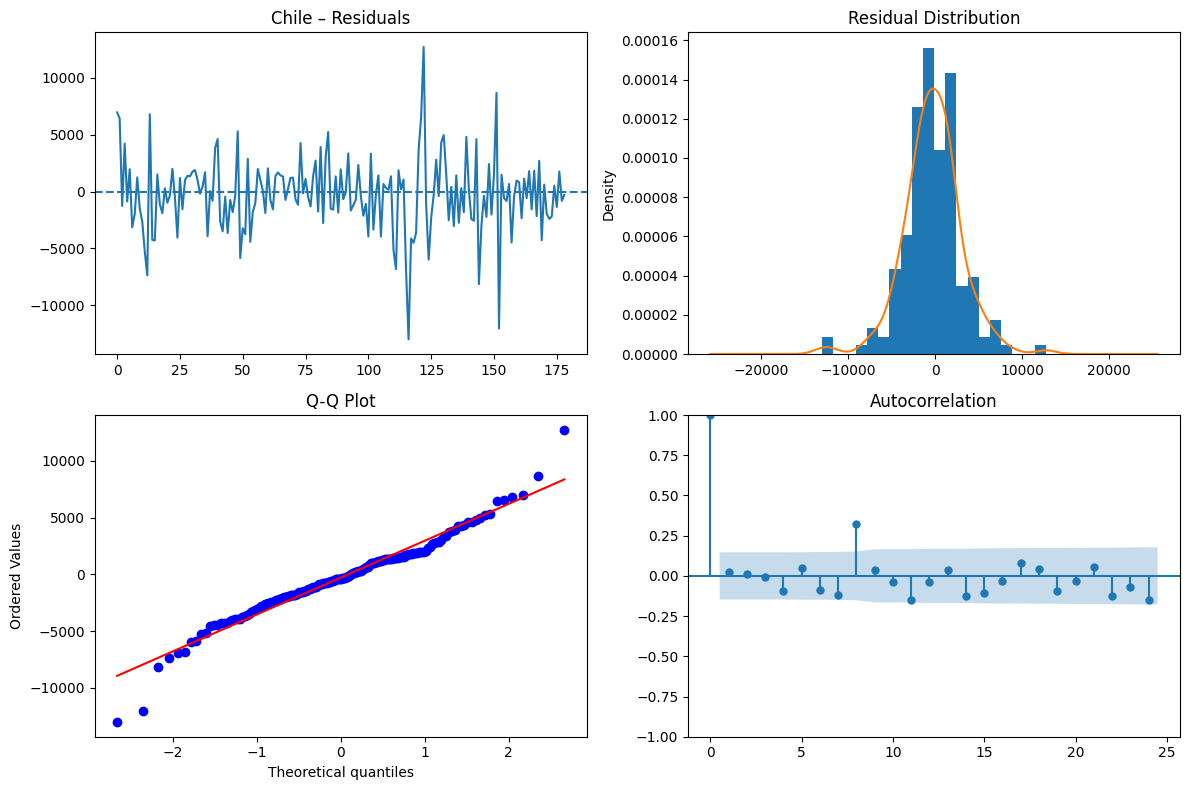


Chile – Ljung-Box Test


,lb_stat,lb_pvalue
12,31.00,0.00


In [ ]:
# Chile residual diagnostics

ch_residuals, ch_lb = residual_diagnostics_sarimax(
    ch_ml,
    target="Vehicle_Sales",
    exog_cols=ch_exog,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    country_name="Chile"
)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


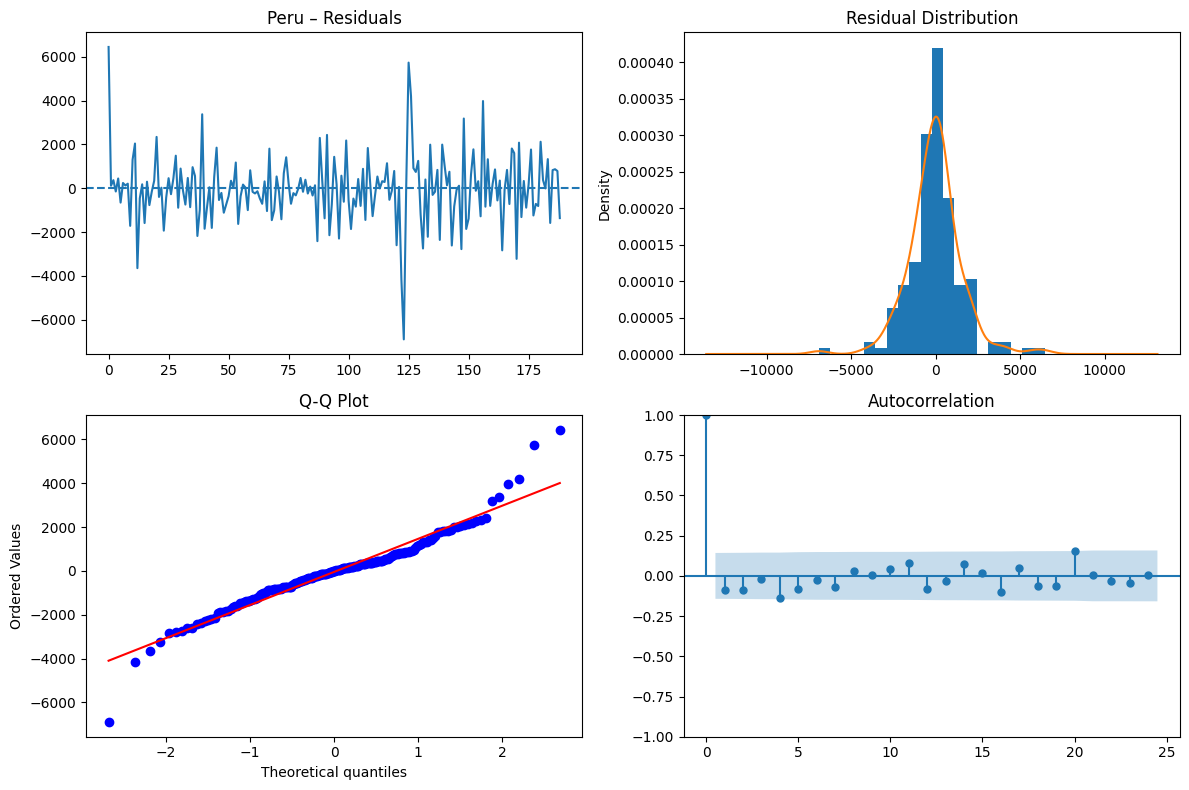


Peru – Ljung-Box Test


,lb_stat,lb_pvalue
12,12.18,0.43


In [ ]:
# Peru residual diagnostics

pe_residuals, pe_lb = residual_diagnostics_sarimax(
    pe_ml,
    target="Vehicle_Sales",
    exog_cols=pe_exog,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    country_name="Peru"
)


In [ ]:
# Sentiment File upload (Colab) – Chile & Peru

from google.colab import files
uploaded = files.upload()   # choose Chile Dataset.zip and Peru Dataset.zip


Saving peru_vehicle_sentiment_2010_2025_populated.xlsx to peru_vehicle_sentiment_2010_2025_populated.xlsx
Saving chile_vehicle_sentiment_2010_2025_populated.xlsx to chile_vehicle_sentiment_2010_2025_populated.xlsx


In [ ]:
display()

In [ ]:
# ============================================================
# Add external news sentiment variable to SARIMAX exogenous data
# ============================================================

# Chile sentiment
ch_sent = pd.read_excel("chile_vehicle_sentiment_2010_2025_populated.xlsx")
ch_sent["Date"] = pd.to_datetime(ch_sent["Date"])

# Peru sentiment
pe_sent = pd.read_excel("peru_vehicle_sentiment_2010_2025_populated.xlsx")
pe_sent["Date"] = pd.to_datetime(pe_sent["Date"])

print(ch_sent.head())
print(pe_sent.head())



        Date                                               Text  \
0 2010-08-01  August reports showed that post-earthquake rec...   
1 2010-09-01  During September, macroeconomic conditions ind...   
2 2010-10-01  October economic news suggested that post-eart...   
3 2010-11-01  In November, economic indicators pointed to a ...   
4 2010-12-01  December reports showed that post-earthquake r...   

   Vehicle Sales Sentiment (-1 to 1)  
0                               0.70  
1                               0.70  
2                               0.70  
3                               0.80  
4                               0.80  
        Date                                               Text  \
0 2010-01-01  During January, economic news pointed to a veh...   
1 2010-02-01  February economic reports indicated that Peru’...   
2 2010-03-01  In March, macroeconomic signals suggested that...   
3 2010-04-01  April data and market commentary showed that P...   
4 2010-05-01  During May, ec

In [ ]:
# Merge sentiment into exogenous datasets
# Create new dataframes that include sentiment
ch_ml_ns = ch_ml.merge(
    ch_sent[["Date", "Vehicle Sales Sentiment (-1 to 1)"]],
    on="Date",
    how="left"
)

pe_ml_ns = pe_ml.merge(
    pe_sent[["Date", "Vehicle Sales Sentiment (-1 to 1)"]],
    on="Date",
    how="left"
)

# Fill missing sentiment values if any
ch_ml_ns["Vehicle Sales Sentiment (-1 to 1)"] = (
    ch_ml_ns["Vehicle Sales Sentiment (-1 to 1)"].fillna(method="ffill")
)

pe_ml_ns["Vehicle Sales Sentiment (-1 to 1)"] = (
    pe_ml_ns["Vehicle Sales Sentiment (-1 to 1)"].fillna(method="ffill")
)

# Define new exogenous column lists including sentiment
ch_exog_ns = ["Inflation Rate", "Bank Lending Rate", "Imports", "Vehicle Sales Sentiment (-1 to 1)"]
pe_exog_ns = ["GDP", "Inflation Rate", "Imports", "Vehicle Sales Sentiment (-1 to 1)"]

print("Chile sentiment merged:", ch_ml_ns[["Date", "Vehicle Sales Sentiment (-1 to 1)"]].head())
print("Peru sentiment merged:", pe_ml_ns[["Date", "Vehicle Sales Sentiment (-1 to 1)"]].head())

print("Chile sentiment merged:", ch_ml_ns[["Date", "Vehicle Sales Sentiment (-1 to 1)"]].tail())
print("Peru sentiment merged:", pe_ml_ns[["Date", "Vehicle Sales Sentiment (-1 to 1)"]].tail())

Chile sentiment merged:         Date  Vehicle Sales Sentiment (-1 to 1)
0 2010-08-01                               0.70
1 2010-09-01                               0.70
2 2010-10-01                               0.70
3 2010-11-01                               0.80
4 2010-12-01                               0.80
Peru sentiment merged:         Date  Vehicle Sales Sentiment (-1 to 1)
0 2010-01-01                               0.80
1 2010-02-01                               0.70
2 2010-03-01                               0.80
3 2010-04-01                               0.90
4 2010-05-01                               0.80
Chile sentiment merged:           Date  Vehicle Sales Sentiment (-1 to 1)
174 2025-02-01                               0.20
175 2025-03-01                               0.30
176 2025-04-01                               0.30
177 2025-05-01                               0.30
178 2025-06-01                               0.30
Peru sentiment merged:           Date  Vehicle Sales 

/tmp/ipykernel_1226/1024042518.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ch_ml_ns["Vehicle Sales Sentiment (-1 to 1)"].fillna(method="ffill")
/tmp/ipykernel_1226/1024042518.py:21: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  pe_ml_ns["Vehicle Sales Sentiment (-1 to 1)"].fillna(method="ffill")


In [ ]:
bt_ch_sarimax_ns = backtest_sarimax(
    ch_ml_ns,
    target="Vehicle_Sales",
    exog_cols=ch_exog_ns,
    n_test=24,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

print("Chile SARIMAX with news sentiment:", bt_ch_sarimax_ns.shape)
bt_ch_sarimax_ns.describe()


/tmp/ipykernel_1226/1464971019.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(start=train_y.index[-1]+1,
/tmp/ipykernel_1226/1464971019.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(start=train_y.index[-1]+1,
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_1226/1464971019.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(start=train_y.index[-1]+1,
/tmp/ipykernel_1226/1464971019.py:40: FutureWarning: Calling float on a s

Chile SARIMAX with news sentiment: (24, 5)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_1226/1464971019.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(start=train_y.index[-1]+1,


,Date,actual,pred,mae,mape
count,24,24.00,24.00,24.00,24.00
mean,2024-06-16 04:00:00,"25,110.50","26,392.51","2,043.57",8.12
min,2023-07-01 00:00:00,"21,044.00","21,587.73",122.37,0.50
25%,2023-12-24 06:00:00,"23,882.25","24,884.66",907.81,4.25
50%,2024-06-16 00:00:00,"25,110.00","26,492.44","1,804.24",7.09
75%,2024-12-08 18:00:00,"25,908.50","28,177.88","3,029.55",12.17
max,2025-06-01 00:00:00,"28,335.00","31,130.78","5,534.53",21.70
std,NaN,"1,912.85","2,656.10","1,401.11",5.52


In [ ]:
bt_pe_sarimax_ns = backtest_sarimax(
    pe_ml_ns,
    target="Vehicle_Sales",
    exog_cols=pe_exog_ns,
    n_test=24,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

print("Peru SARIMAX with news sentiment:", bt_pe_sarimax_ns.shape)
bt_pe_sarimax_ns.describe()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_1226/1464971019.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(start=train_y.index[-1]+1,
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: Convergenc

Peru SARIMAX with news sentiment: (24, 5)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_1226/1464971019.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pred = float(fit.predict(start=train_y.index[-1]+1,


,Date,actual,pred,mae,mape
count,24,24.00,24.00,24.00,24.00
mean,2024-09-15 13:00:00,"13,460.46","13,364.58","1,051.30",7.95
min,2023-10-01 00:00:00,"10,837.00","10,396.30",139.49,1.09
25%,2024-03-24 06:00:00,"12,294.50","12,558.08",640.94,4.89
50%,2024-09-16 00:00:00,"13,369.00","13,493.87",970.61,6.77
75%,2025-03-08 18:00:00,"14,499.75","14,027.36","1,483.29",10.09
max,2025-09-01 00:00:00,"16,629.00","16,252.04","2,736.04",23.61
std,NaN,"1,563.59","1,399.05",623.89,5.15


In [ ]:
[x for x in globals().keys() if x.startswith("bt_")]


['bt_ch_sarima',
 'bt_pe_sarima',
 'bt_ch_sarimax',
 'bt_pe_sarimax',
 'bt_ch_sarimax_ns',
 'bt_pe_sarimax_ns']

In [ ]:
def summarise_backtest(bt_df, country, model_name):
    return {
        "Country": country,
        "Model": model_name,
        "MAE_mean": bt_df["mae"].mean(),
        "MAPE_mean": bt_df["mape"].mean()
    }

summary_sarima = pd.DataFrame([
    summarise_backtest(bt_ch_sarima,  "Chile", "SARIMA"),
    summarise_backtest(bt_ch_sarimax, "Chile", "SARIMAX"),
    summarise_backtest(bt_ch_sarimax_ns, "Chile", "SARIMAX + News"),
    summarise_backtest(bt_pe_sarima,  "Peru",  "SARIMA"),
    summarise_backtest(bt_pe_sarimax, "Peru",  "SARIMAX"),
    summarise_backtest(bt_pe_sarimax_ns, "Peru",  "SARIMAX + News")
]).sort_values(["Country", "MAPE_mean"])

summary_sarima

,Country,Model,MAE_mean,MAPE_mean
1,Chile,SARIMAX,"1,770.10",7.03
2,Chile,SARIMAX + News,"2,043.57",8.12
0,Chile,SARIMA,"2,110.48",8.36
3,Peru,SARIMA,942.38,7.11
5,Peru,SARIMAX + News,"1,051.30",7.95
4,Peru,SARIMAX,"1,181.60",8.80


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


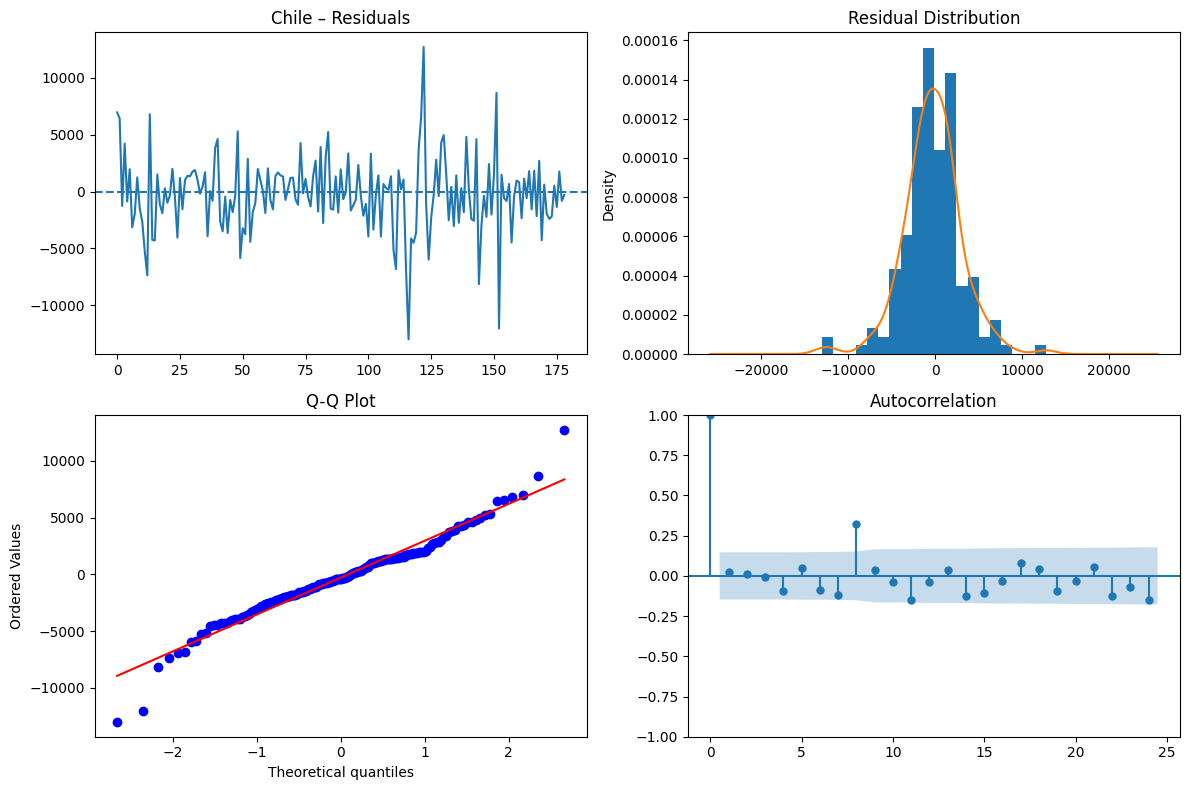


Chile – Ljung-Box Test


,lb_stat,lb_pvalue
12,31.00,0.00


In [ ]:
# Chile residual diagnostics

ch_residuals, ch_lb = residual_diagnostics_sarimax(
    ch_ml,
    target="Vehicle_Sales",
    exog_cols=ch_exog,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    country_name="Chile"
)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


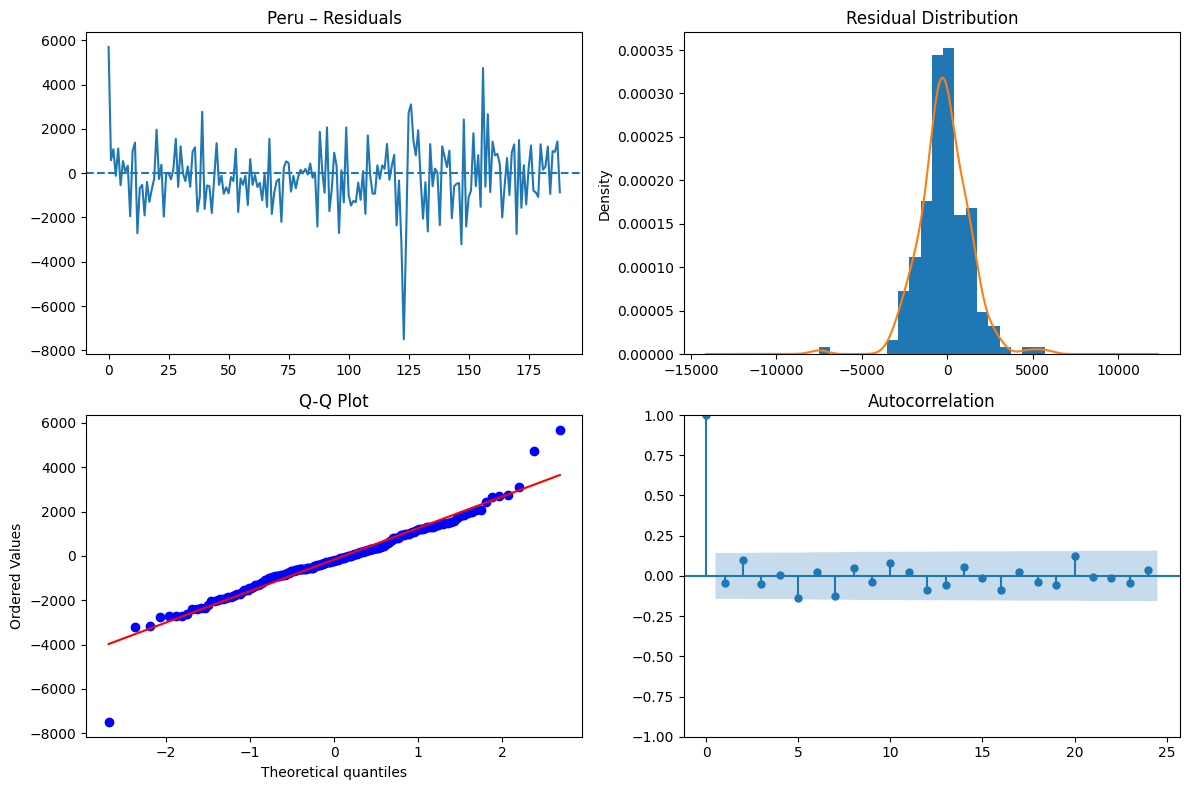


Peru – Ljung-Box Test


,lb_stat,lb_pvalue
12,13.23,0.35


In [ ]:
# Peru residual diagnostics

pe_residuals_ns, pe_lb_ns = residual_diagnostics_sarimax(
    pe_ml_ns,
    target="Vehicle_Sales",
    exog_cols=pe_exog_ns,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    country_name="Peru"
)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


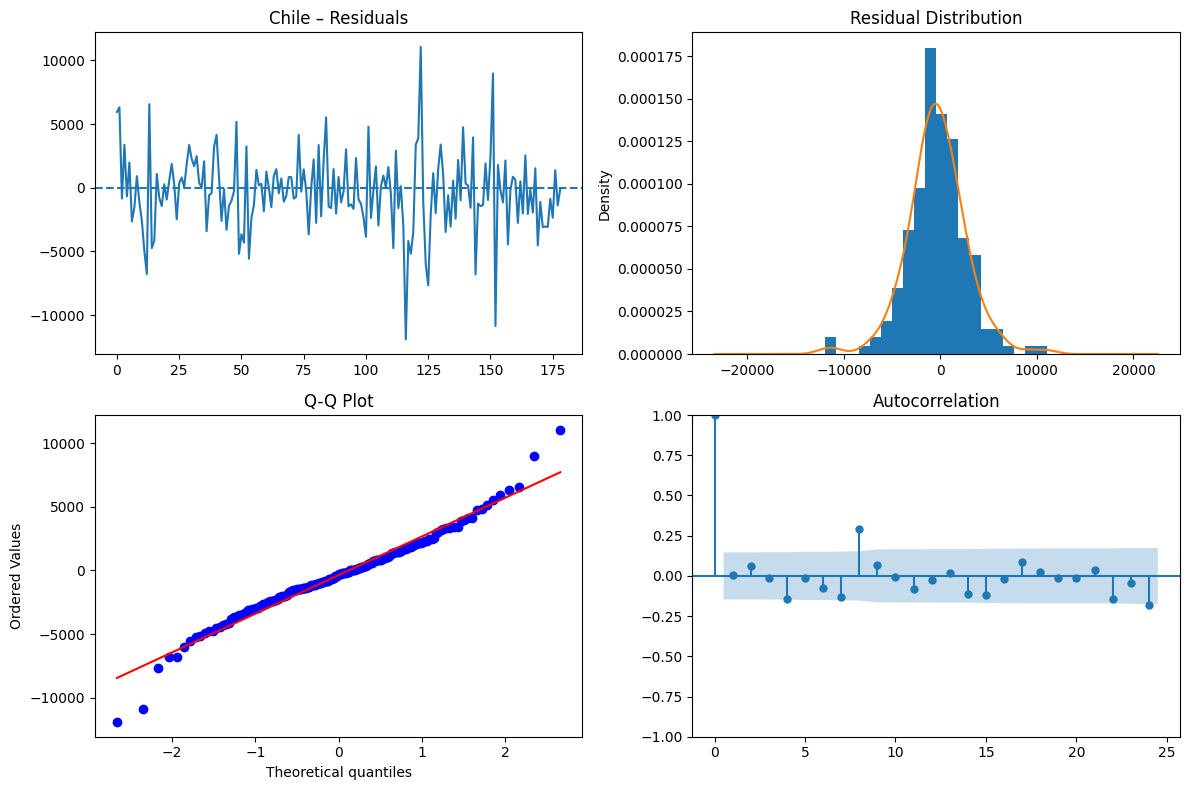


Chile – Ljung-Box Test


,lb_stat,lb_pvalue
12,27.33,0.01


In [ ]:
# Chile residual diagnostics

ch_residuals_ns, ch_lb_ns = residual_diagnostics_sarimax(
    ch_ml_ns,
    target="Vehicle_Sales",
    exog_cols=ch_exog_ns,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    country_name="Chile"
)


In [ ]:
summary_lb_test = pd.DataFrame({
    "country": ["Chile", "Chile", "Peru", "Peru"],
    "model": ["sarimax", "sarimax_ns", "sarimax", "sarimax_ns"],
    "lb_stat": [
        ch_lb["lb_stat"].iloc[0],
        ch_lb_ns["lb_stat"].iloc[0],
        pe_lb["lb_stat"].iloc[0],
        pe_lb_ns["lb_stat"].iloc[0],
    ],
    "lb_pvalue": [
        ch_lb["lb_pvalue"].iloc[0],
        ch_lb_ns["lb_pvalue"].iloc[0],
        pe_lb["lb_pvalue"].iloc[0],
        pe_lb_ns["lb_pvalue"].iloc[0],
    ]
})

summary_lb_test

,country,model,lb_stat,lb_pvalue
0,Chile,sarimax,31.00,0.00
1,Chile,sarimax_ns,27.33,0.01
2,Peru,sarimax,12.18,0.43
3,Peru,sarimax_ns,13.23,0.35


## **Sarimax vs Sarimax + News sentiment**
*Analysis of residuals*

Residual diagnostics showed that SARIMAX models for Peru produced approximately white-noise residuals, indicating that most temporal structure was captured successfully. In contrast, Chile residuals retained statistically significant autocorrelation, suggesting more complex underlying dynamics and potential limitations of the model. Adding news sentiment as an exogenous variable slightly improved residual behaviour in Chile, reducing the Ljung–Box statistic from 31.00 to 27.33 and increasing the p-value from 0.00 to 0.01, but residual autocorrelation remained statistically significant. For Peru, adding news sentiment did not materially improve residual diagnostics, as both models already passed the Ljung–Box test comfortably.

| Country | Model      | p-value | Interpretation                              |
| ------- | ---------- | ------- | ------------------------------------------- |
| Chile   | sarimax    | 0.00    | Strong evidence of residual autocorrelation |
| Chile   | sarimax_ns | 0.01    | Residual autocorrelation still present      |
| Peru    | sarimax    | 0.43    | Residuals behave like white noise           |
| Peru    | sarimax_ns | 0.35    | Residuals behave like white noise           |


## **Sarimax vs Sarimax + News sentiment**
### **Conclusions**

*Chile Interpretation:*
Best model: SARIMAX|
Lowest MAPE: 7.03%|

This suggests that:
1. Eexternal regressors added useful predictive information
2. Chile vehicle sales are influenced by external/economic drivers captured in the exogenous variables incorporating those signals improved forecast precision versus a purely univariate SARIMA model
3. Adding news sentiment reduced performance:
Model	MAPE
SARIMAX	7.03%
SARIMAX + News	8.12%
The sentiment signal may have been noisy.
However residual diagnostics showed that news sentiment slightly improved residual behaviour

*Peru Interpretation:*
Best model: SARIMA|
Lowest MAPE: 7.11%|

This suggests:
1. Peru sales dynamics were largely captured by historical autoregressive and seasonal structure alone
2. Exogenous variables added limited incremental predictive value
3. Peru residuals already behaved like white noise meaning the temporal structure was already well captured without needing additional signals


## 12-month forecast plots with SARIMAX (macro-driven)

In [ ]:
import matplotlib.pyplot as plt

def forecast_sarimax_12m(df, target, exog_cols, order, seasonal_order,
                         country_name, title_suffix="SARIMAX forecast",
                         steps=12):

    df_fc = df.sort_values("Date").reset_index(drop=True).copy()
    y = df_fc[target]

    if exog_cols is not None:
        exog = df_fc[exog_cols]
    else:
        exog = None

    # Fit on full history
    model = SARIMAX(y, exog=exog, order=order, seasonal_order=seasonal_order)
    res = model.fit(disp=False)

    # Build future exog by repeating the last row (simple assumption)
    if exog_cols is not None:
        last_exog = exog.iloc[[-1]].values
        future_exog = np.repeat(last_exog, steps, axis=0)
    else:
        future_exog = None

    # Forecast
    fc_res = res.get_forecast(steps=steps, exog=future_exog)
    fc_mean = fc_res.predicted_mean
    fc_ci   = fc_res.conf_int()

    # Build future date index (monthly)
    last_date = df_fc["Date"].iloc[-1]
    future_dates = pd.date_range(last_date + pd.offsets.MonthBegin(1),
                                 periods=steps, freq="MS")

    # Plot: last 5 years of history + forecast
    history_window = 60  # months
    y_hist = y.iloc[-history_window:]
    dates_hist = df_fc["Date"].iloc[-history_window:]

    plt.figure(figsize=(10,5))
    plt.plot(dates_hist, y_hist, label="Actual (last 5 years)")
    plt.plot(future_dates, fc_mean, label="Forecast (next 12 months)")

    plt.fill_between(
        future_dates,
        fc_ci.iloc[:,0],
        fc_ci.iloc[:,1],
        alpha=0.2,
        label="95% confidence interval"
    )

    plt.title(f"{country_name} – {title_suffix}")
    plt.xlabel("Date")
    plt.ylabel("Vehicle Sales")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Return forecast values for inspection if needed
    return pd.DataFrame({
        "Date": future_dates,
        "Forecast": fc_mean.values,
        "Lower": fc_ci.iloc[:,0].values,
        "Upper": fc_ci.iloc[:,1].values
    })


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


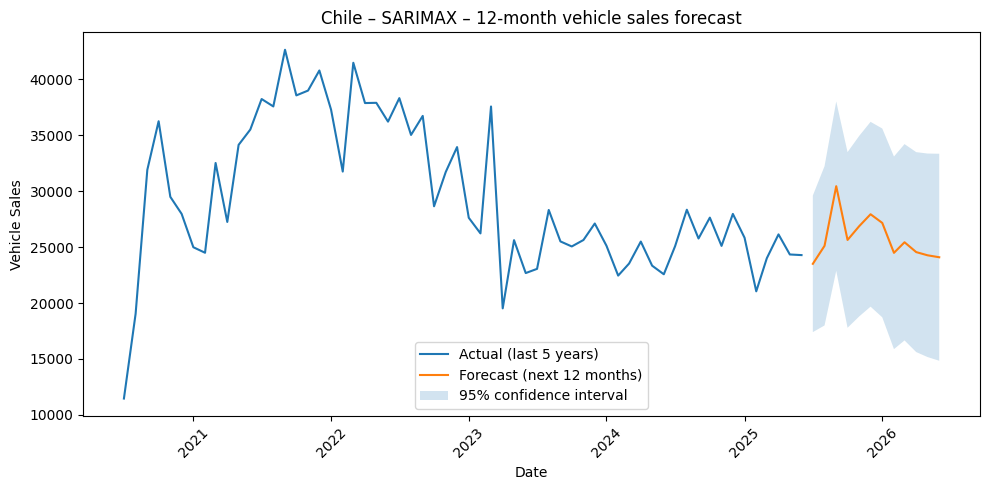

,Date,Forecast,Lower,Upper
0,2025-07-01,"23,501.46","17,399.48","29,603.43"
1,2025-08-01,"25,109.27","17,993.07","32,225.47"
2,2025-09-01,"30,439.92","22,873.60","38,006.25"
3,2025-10-01,"25,634.05","17,786.38","33,481.73"
4,2025-11-01,"26,870.20","18,804.25","34,936.15"


In [ ]:
ch_exog = ["Inflation Rate", "Bank Lending Rate", "Imports"]

ch_forecast_12m = forecast_sarimax_12m(
    ch_ml,
    target="Vehicle_Sales",
    exog_cols=ch_exog,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    country_name="Chile",
    title_suffix="SARIMAX – 12-month vehicle sales forecast"
)

ch_forecast_12m.head()


### Chile – SARIMAX 12-Month Vehicle Sales Forecast
- The forecast indicates broadly stable demand, with monthly sales centred around the mid-20,000 range.

- No clear upward or downward trend is evident, implying a flat demand outlook over the next 12 months.

- Forecast uncertainty increases with horizon, as reflected by widening confidence intervals.

- Short-term projections remain close to recent observations, while longer-term estimates become less precise.

**Key takeaway:**  
SARIMAX suggests stable near-term vehicle sales in Chile, making it well suited for short-term planning and risk assessment, but less reliable for precise long-horizon forecasting



/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


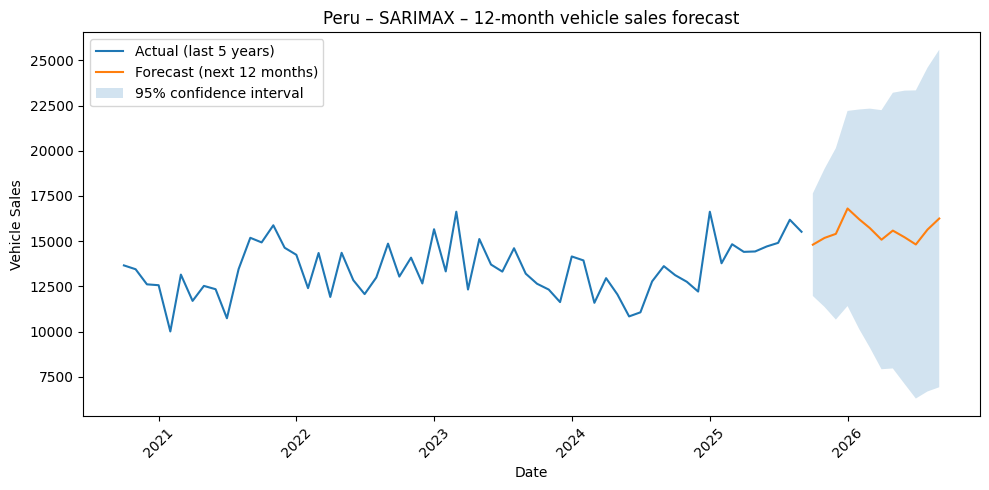

,Date,Forecast,Lower,Upper
0,2025-10-01,"14,805.22","11,967.54","17,642.91"
1,2025-11-01,"15,180.07","11,360.33","18,999.81"
2,2025-12-01,"15,404.26","10,660.02","20,148.51"
3,2026-01-01,"16,807.49","11,408.52","22,206.45"
4,2026-02-01,"16,208.36","10,130.56","22,286.17"


In [ ]:
pe_exog = ["GDP", "Inflation Rate", "Imports"]

pe_forecast_12m = forecast_sarimax_12m(
    pe_ml,
    target="Vehicle_Sales",
    exog_cols=pe_exog,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    country_name="Peru",
    title_suffix="SARIMAX – 12-month vehicle sales forecast"
)

pe_forecast_12m.head()


### Peru – SARIMAX 12-Month Vehicle Sales Forecast

- The model projects monthly sales in the 14,000–16,000 range, indicating broadly stable demand.

- No strong upward or downward trend is evident, with only mild month-to-month variation.

- Forecast uncertainty widens with horizon, reflecting sensitivity to future macroeconomic conditions.

- Short-term forecasts remain close to recent observations, while longer-term precision is limited.

**Key takeaway**
For Peru, SARIMAX indicates a stable but uncertain outlook.
The model is most useful for short-term directional insight and risk awareness, rather than precise long-horizon volume forecasting.


## SARIMAX forecast charts

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def plot_sarimax_backtest_24(bt_df, country, mae, mape, save_path=None):
    """
    Recreate the original SARIMAX backtest chart on the last 24 months.

    bt_df must have columns: 'Date', 'actual', 'pred'
    """
    df = bt_df.copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df_24 = df.tail(24)

    fig, ax = plt.subplots(figsize=(10, 4.5))

    ax.plot(df_24["Date"], df_24["actual"],
            label="Actual", color="#003f5c", linewidth=2.2)
    ax.plot(df_24["Date"], df_24["pred"],
            label="SARIMAX prediction", color="#ffa600",
            linestyle="--", linewidth=2.2)

    ax.set_title(
        f"{country} – SARIMAX Backtest (24-month rolling)\n"
        f"MAE: {mae:,.0f}   MAPE: {mape:.2f}%",
        fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Vehicle sales")

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(frameon=True)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved backtest chart to: {save_path}")
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def plot_sarimax_12m_hist_forecast(
    hist_df,
    bt_df,
    fcst_df,
    hist_start_date,
    last_actual_date,
    country,
    mae,
    mape,
    save_path=None,
):
    """
    Inchcape-style SARIMAX chart:
    - 12-month history window (Actual)
    - SARIMAX backtest over that same period (dashed)
    - 12-month SARIMAX forecast (solid), re-indexed so it starts
      the month after last_actual_date (no gap).
    """

    # --- 0. Copies & dates ---
    hist = hist_df.copy()
    bt   = bt_df.copy()
    fcst = fcst_df.copy()

    hist["Date"] = pd.to_datetime(hist["Date"])
    bt["Date"]   = pd.to_datetime(bt["Date"])

    hist_start_date  = pd.to_datetime(hist_start_date)
    last_actual_date = pd.to_datetime(last_actual_date)

    # --- 1. 12-month history window ---
    mask_hist = (hist["Date"] >= hist_start_date) & (hist["Date"] <= last_actual_date)
    hist_win = hist.loc[mask_hist, ["Date", "Vehicle_Sales"]].copy()

    # align SARIMAX backtest to those same dates
    bt_win = bt.merge(hist_win[["Date"]], on="Date", how="inner")

    # --- 2. Build a clean 12-month forecast index from last_actual_date ---
    # use first 12 forecast values, but ignore their original dates
    fcst_vals = fcst["Forecast"].values[:12]
    fcst_dates = pd.date_range(
        last_actual_date + pd.offsets.MonthBegin(1),
        periods=12,
        freq="MS",
    )

    # y-value of the last observed point
    last_y = hist_win.loc[hist_win["Date"] == last_actual_date, "Vehicle_Sales"].iloc[0]

    # --- 3. Plot ---
    fig, ax = plt.subplots(figsize=(10, 4.5))

    # actual history
    ax.plot(
        hist_win["Date"],
        hist_win["Vehicle_Sales"],
        label="Actual sales (last 12 months)",
        color="#003f5c",
        linewidth=2.4,
    )

    # SARIMAX backtest over same window
    ax.plot(
        bt_win["Date"],
        bt_win["pred"],
        label="SARIMAX prediction (backtest)",
        color="#ffa600",
        linestyle="--",
        linewidth=2.2,
    )

    # SARIMAX forecast (next 12m) – now directly after last_actual_date
    ax.plot(
        fcst_dates,
        fcst_vals,
        label="SARIMAX forecast (next 12 months)",
        color="#2f4b7c",
        linewidth=2.6,
    )

    # last observed point
    ax.scatter(
        [last_actual_date],
        [last_y],
        color="#003f5c",
        s=55,
        zorder=5,
        label="Last observed",
    )

    # vertical line at forecast start
    ax.axvline(
        x=last_actual_date,
        color="grey",
        linestyle="--",
        linewidth=1.4,
        alpha=0.8,
        label="Forecast start",
    )

    # forecast annotation
    ax.text(
        last_actual_date,
        ax.get_ylim()[1] * 0.98,
        "Forecast\nbegins here",
        ha="left",
        va="top",
        fontsize=9,
        color="dimgray",
    )

    # --- 4. Styling ---
    ax.set_title(
        f"{country} – SARIMAX model\n"
        f"12-month backtest + 12-month forecast",
        fontsize=13,
        fontweight="bold",
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Vehicle sales")

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    ax.grid(True, linestyle="--", alpha=0.3)

    # MAE/MAPE box
    box_text = f"MAE: {mae:,.0f}\nMAPE: {mape:.2f}%"
    ax.text(
        0.98,
        0.98,
        box_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", fc="#f4f4f0", ec="#333333"),
    )

    ax.legend(frameon=True, loc="upper left")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved SARIMAX chart to: {save_path}")

    plt.show()


Saved SARIMAX chart to: Chile_SARIMAX_12m_hist_forecast.jpg


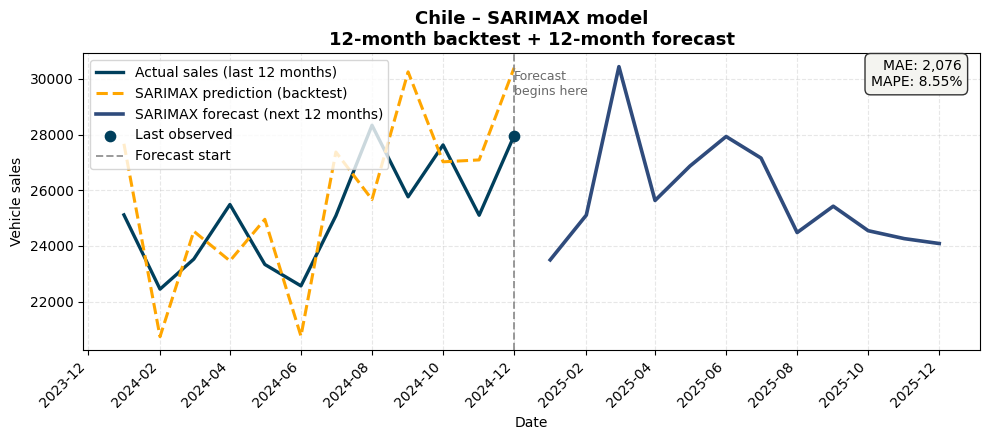

Saved SARIMAX chart to: Peru_SARIMAX_12m_hist_forecast.jpg


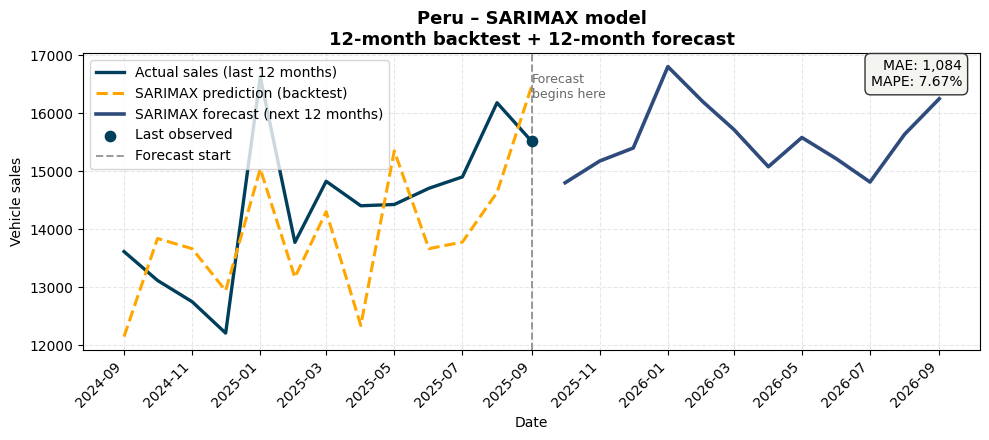

In [ ]:
# Chile
plot_sarimax_12m_hist_forecast(
    hist_df          = ch_ml,
    bt_df            = bt_ch_sarimax,
    fcst_df          = ch_forecast_12m,
    hist_start_date  = "2024-01-01",
    last_actual_date = "2024-12-01",
    country          = "Chile",
    mae              = 2075.75,
    mape             = 8.55,
    save_path        = "Chile_SARIMAX_12m_hist_forecast.jpg",
)

# Peru
plot_sarimax_12m_hist_forecast(
    hist_df          = pe_ml,
    bt_df            = bt_pe_sarimax,
    fcst_df          = pe_forecast_12m,
    hist_start_date  = "2024-09-01",
    last_actual_date = "2025-09-01",
    country          = "Peru",
    mae              = 1084.04,
    mape             = 7.67,
    save_path        = "Peru_SARIMAX_12m_hist_forecast.jpg",
)
